# Notebook for generating and saving subplots of the fig4 and fig 5 in the paper   
The EmbryoAnalysis is copied and modified from the original `notebooks/metrics&figures.py`

Day last updated: 11/08/2025

Required model checkpoint paths:
- mouse : `pl_trainer_log/True_mESC_featv5_c20_ST_DeepDecay_mul_identity_lr0.0003_L20.4_T0.5/mouse`
- livestock : `pl_trainer_log/True_CHO_featv5_c20_ST_DeepDecay_mul_identity_lr0.0003_L20.5_T0.5/species`

Image saved to:
- mouse (fig4) : `results/pub_figures/mouse_mESC`
- livestock (fig5) : `results/pub_figures/livestock_CHO_Aug11`

In [13]:
# drar hist for all guides
%load_ext autoreload
%autoreload 2
import os, sys

import re
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')
from inDecay import PATH,my_utils
os.chdir(PATH.main_dir)
from inDecay.models import Topk_Event_Overlapping
from tqdm.auto import tqdm
import pickle as pkl
from scipy.stats import pearsonr
# from qrguide import analysis_fn, transformation
pj = os.path.join
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns
from io import StringIO
import shutil
# ! pip install more_itertools
import more_itertools as mit
from adjustText import adjust_text
from inDecay.analysis_fn import assessment_recipe_forecast_zygote, assessment_recipe_32IDL
from collections import defaultdict
from scipy.stats import pearsonr

class EmbryoAnalysis:
    def __init__(self, cell, archive_folder, foldnum, metrics_to_show, r2=0.8, count= 700,  show_other_tool=True, dpi=30):
        
        self.cell = cell
        self.archive_folder = archive_folder
        self.species = archive_folder.split("/")[-1]
        self.dpi = dpi
        self.foldnum = foldnum
        self.show_other_tool = show_other_tool
        self.r2=r2
        self.count = count
        self.metrics_to_show = metrics_to_show
        # Path stubs for offline tools
        self.Y_forc = 'results/FORECasT.pkl'
        self.Y_lindel = 'results/Lindel.pkl'
        self.Y_inDelphi = 'results/inDelphi.pkl'
        # Data placeholders
        self.species_dict={'m': 'Mouse', 'g':'Goat', 's':'Sheep', 'c':'Cattle', 'p': 'Porcine'}
        self.df_raws, self.melt_dfs = self.process_folds()
        self.perform_df, self.ratio_df = self.get_performance()
        self.metric_fig, self.by_gene, self.perform_m, self.perform_n =self.plot_all_metrics()

        
    def r2selected(self, r2, count):
        gene_seq=pd.read_csv(pj(PATH.data_dir, 'gene_seq.csv'),index_col=0)
        selected = gene_seq[(gene_seq['r2'] > r2) & (gene_seq['count'] >= count)]
        return selected.sort_values(by='r2', ascending=False).index
    def read_pkl(self, path):
        import pickle
        with open(path, 'rb') as f:
            return pickle.load(f)
    def process_y(self, pkl, indel):
        pkl_idl=pkl.T[0]
        pkldict= {idl: pkl.T[1][i] for i, idl in enumerate(pkl_idl)}
        pkl_ordered= [pkldict[idl] if idl in pkldict.keys() else 0 for idl in indel ]
        pkl_value_norm= pkl_ordered/np.sum(pkl_ordered)
        return np.array([pkl_value_norm])

    def get_patterns(self, Y_true_path, Y_pred_path, Y_baseline, Y_forc, Y_indephi, Y_lindel, IDL= False):
        Y_pred = self.read_pkl(Y_pred_path)
        Y_lookup = self.read_pkl(Y_true_path)
        Y_b = self.read_pkl(Y_baseline)
        Y_f = self.read_pkl(Y_forc)
        Y_i = self.read_pkl(Y_indephi)
        Y_l = self.read_pkl(Y_lindel)
        dicts={}
        for oligo, Y in Y_lookup.items():
            Y = Y.T
            indel = Y[0, :]
            y = Y[1, :].astype('float32')
            pred_lookup = Y_pred[oligo][0]
            base_lookup = Y_b[oligo][0]
            forc_lookup= self.process_y(Y_f[oligo], indel)[0]
            indel_lookup= self.process_y(Y_i[oligo], indel)[0]
            lindel_lookup= self.process_y(Y_l[oligo], indel)[0]

            if IDL is True:
                Indel_IDL= [ind.split('_')[0] for ind in indel]
            else:
                Indel_IDL= [ind.split('_')[0] if ind.startswith('I') else ind for ind in indel]
            pred_IDL = defaultdict(float)
            base_IDL = defaultdict(float)
            y_IDL = defaultdict(float)
            l_IDL=defaultdict(float)
            f_IDL=defaultdict(float)
            i_IDL=defaultdict(float)
            for k, v in zip(Indel_IDL, pred_lookup):
                pred_IDL[k]+=v
            for k, v in zip(Indel_IDL, base_lookup):
                base_IDL[k]+=v
            for k, v in zip(Indel_IDL, y):
                y_IDL[k]+=v
            for k, v in zip(Indel_IDL, lindel_lookup):
                l_IDL[k]+=v
            for k, v in zip(Indel_IDL, forc_lookup):
                f_IDL[k]+=v
            for k, v in zip(Indel_IDL, indel_lookup):
                i_IDL[k]+=v

            df = pd.DataFrame({
            'observed': pd.Series(y_IDL),
            'fewshot': pd.Series(pred_IDL),
            'pretrained': pd.Series(base_IDL),
            'FORECasT': pd.Series(f_IDL),
            'inDelphi': pd.Series(i_IDL),
            'Lindel': pd.Series(l_IDL)
        })
            df = df.sort_values('observed', ascending=False)
            
        return oligo, df

    def select_top_k(self, cols, include_tools=True, k=3):
        observed = np.array(cols['observed'])
        n_val = np.count_nonzero(observed)
        k_actual = min(k, n_val)
        idx_sets = [
            np.argpartition(cols[col].to_numpy(), -k_actual if col == 'observed' else -k)[-k_actual if col == 'observed' else -k:]
            for col in ['fewshot', 'observed', 'pretrained']
        ]
        idx = set().union(*idx_sets)
        if include_tools:
            extra_cols = ['FORECasT', 'inDelphi', 'Lindel']
            for col in extra_cols:
                idx = idx.union(set(np.argpartition(cols[col].to_numpy(), -k)[-k:]))
            df_idx_cols = [
                'Indel', 'observed', 'pretrained', 'fewshot', 'inDelphi', 'Lindel', 'FORECasT'
            ]
        else:
            df_idx_cols = ['Indel', 'observed', 'pretrained', 'fewshot']
        df_idx = cols.loc[list(idx), df_idx_cols].sort_values('observed', ascending=False).set_index('Indel')
        return df_idx

    def return_paths(self, fold_idx):
        second_save_path = f"{self.foldnum}fold_{fold_idx}"
        Y_true = pj(self.archive_folder, second_save_path, "ForeCast_TestY.pkl")
        Y_baseline = pj(self.archive_folder, second_save_path, "Pretrained_Baseline_TestPred.pkl")
        lightning_logs_path = pj(self.archive_folder, second_save_path, "lightning_logs")
        ckpt_path = my_utils.find_ckpt(lightning_logs_path)
        if ckpt_path is None:
            raise FileNotFoundError(f"No checkpoint found in {lightning_logs_path}")
        Y_pred_path = ckpt_path.replace(".ckpt", "TestPred.pkl")
        return Y_true, Y_baseline, Y_pred_path

    def process_folds(self):
        perform_frames, ratio_frames = [], []
        melt_dfs ={}
        df_raws={}

        for k_idx in range(self.foldnum):
            Y_true_path, Y_baseline_path, Y_pred_path = self.return_paths(k_idx)
            oligo, df_raw = self.get_patterns(
                Y_true_path, Y_pred_path, Y_baseline_path, self.Y_forc, self.Y_inDelphi, self.Y_lindel
            )
            if oligo in self.r2selected(r2= self.r2, count=self.count):
                df= df_raw.reset_index().rename(columns={'index':'Indel'}).groupby('Indel').agg('sum')
                df_raws[oligo]=df
                df_col = pd.DataFrame.from_dict(df).reset_index()
                cols_selection = self.select_top_k(cols=df_col, include_tools=self.show_other_tool, k=2)
                cols_selection = cols_selection.sort_values('observed', ascending=False)
                melt_df = cols_selection.reset_index().melt(id_vars=['Indel'], var_name='model')
                melt_dfs[oligo]=melt_df
        return df_raws, melt_dfs

    def get_performance(self):
        ratio_frames= defaultdict(list)
        perform_frames= defaultdict(list)
        for oligo, df_raw in self.df_raws.items():
            perform = assessment_recipe_forecast_zygote({oligo: df_raw})
            perform_IDL = assessment_recipe_32IDL({oligo: df_raw})
            ratio_frames["Gene"].append(oligo)
            for model, metrics in perform.items():
                perform_frames['cell'].append(self.cell)
                perform_frames['fix_setting'].append(model)
                for metric, values in metrics.items():
                    if 'ratio' in metric:
                        ratio_value= values[0] if len(values)==1 else values
                        ratio_frames[f"{model}_{metric}"].append(ratio_value)
                    else:
                        if isinstance(values, list) and len(values) == 1:
                            perform_frames[metric].append(values[0])
                        else:
                            perform_frames[metric].append(values)
            for model, metrics in perform_IDL.items():
                for metric, values in metrics.items():
                    if metric !='OligoID':
                        perform_frames[metric].append(values)
        print(f'Only high-quality (r2 >{self.r2} and count >{self.count}) samples (count = {len(self.df_raws)}) were considered for performance metrics')
        perform_df = pd.DataFrame.from_dict(perform_frames)
        ratio_df = pd.DataFrame.from_dict(ratio_frames).set_index('Gene')
        return perform_df, ratio_df

                

    def draw_metrics(self, save_dir=None):
        def plot_legend(color_palette):
            """
            Create a separate legend figure
            """
            
            # Create figure for legend
            fig, ax = plt.subplots(figsize=(1, 4), dpi=300)
            
            # Create dummy plot elements for legend
            legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, label=label) 
                            for label, color in color_palette.items()]
            
            # Create legend
            legend = ax.legend(handles=legend_elements, loc='center', ncol=1, frameon=False)
            ax.axis('off')  # Hide axes
            
            # Adjust layout and save/show
            plt.tight_layout()
            return fig

        fig_ls = []
        for oligo, melt_df in self.melt_dfs.items():
            # melt_df['model'] = melt_df['model'].replace({
            #     'pretrained': 'mESC-inDecay',
            #     'fewshot': 'Embryo-inDecay',
            #     'observed': 'Experimental-DATA'
            # })
            color_palette = {
                'observed': '#c27c44','pretrained': '#677e98', 'fewshot': '#ceac2d', 
                'FORECasT': 'darksalmon', 'inDelphi': '#9c9376', 'Lindel': 'olive'
            }
            fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
            sns.barplot(data=melt_df, x='value', y='Indel', hue='model',
                        edgecolor='white', linewidth=0.5, palette=color_palette, saturation=1, ax=ax)
            sns.despine(ax=ax)
            ax.set_xlabel('frequency')
            ax.set_ylabel('indels')
            # ax.legend(title='', loc='lower right')
            ax.legend().set_visible(False)
            ax.set_title(f'{self.species_dict[oligo[0]]}_{oligo}', fontsize=15)
            plt.show()

            fig_ls.append(fig)
            if save_dir is not None and os.path.exists(save_dir):
                fig.savefig(pj(save_dir, f'{oligo}.pdf'), dpi=600, transparent=True, bbox_inches='tight')
        legend_fig = plot_legend(color_palette)
        legend_fig.savefig(pj(save_dir, f'legend.pdf'), dpi=600, transparent=True, bbox_inches='tight')

        fig_ls.append(legend_fig)

        return fig_ls

    def plot_all_metrics(self):

        color_palette = {
            'pretrained': '#677e98', 'fewshot': '#ceac2d', 'observed': '#c27c44',
            'FORECasT': 'darksalmon', 'inDelphi': '#9c9376', 'Lindel': 'olive'
        }
        def extract_and_prep(setting):
            df = self.perform_df.query(f"`fix_setting`=='{setting}'").set_index('OligoID')
            return df
        def to_melt(df, model): 
            melt = df[self.metrics_to_show].melt() if all(metric in df.columns for metric in self.metrics_to_show) else pd.DataFrame()
            melt['model'] = model 
            return melt
        by_gene=[]
        for model in color_palette.keys():
            try:
                # Create the dataframe for this model
                model_df = extract_and_prep(model)
                if not model_df.empty:
                    by_gene.append(to_melt(model_df, model))
            except Exception as e:
                print(f"Warning: Could not process model {model}: {e}")
                continue
            
        by_gene = pd.concat(by_gene)
        by_gene = by_gene.reset_index(drop=True)
        by_gene.to_csv('results/whole_finetuned_mouse_2025.csv')
        by_gene.groupby(['variable','model']).mean(numeric_only=True).reset_index().to_csv('results/finetuned_mouse_2025.csv')
        # label_map = {
        #     [ 'Coll_I_Major_Top1', 'abs_frameshift_error', 'Coll_I_Major0.25', 'Coll_I_Kendall_Top3', 'KL Divergence']
        # }
        # by_gene['variable'] = by_gene['variable'].map(label_map)
        by_gene = by_gene.sort_values("model", ascending=True)
        sns.set_theme(style='ticks')
        fig, axs = plt.subplots(1, len(self.metrics_to_show), figsize=(len(self.metrics_to_show)*3, 2.5), dpi=self.dpi, gridspec_kw={'wspace': 0.3})
        xlabels = ['Lindel', 'inDelphi', 'FORECasT', 'pretrained', 'fewshot']
        # Define custom ylim for each metric

        if self.species == "mouse":
            ylim_settings = {
                'Top5 event recall': (1.7, 3.5),
                'Major(0.25) event recall': (0.2, 1),
                'Kendall_Top5': (-0.2, 0.5),
                'abs frameshift error': (0.04, 0.18),
                'KLD_IDL': (0.25, 5)
            }
        elif self.species == "species":
            # species
            ylim_settings = {
                'Top1 event recall': (0, 1.1),
                'Major(0.25) event recall': (0.0, 1),
                'abs frameshift error': (0.02, 0.25),
                'KLD_IDL': (0.25, 2.9)
            }
        else: 
            raise ValueError("Invalid species")


        for i, col in enumerate(self.metrics_to_show):
            sns.barplot(data=by_gene.query(f"`variable` == '{col}'"), 
                        x='model', y='value', width=0.6, ax=axs[i], 
                        palette=color_palette, order=xlabels)

            sns.despine(ax=axs[i])
            
            # Apply custom ylim for each metric
            if col in ylim_settings:
                axs[i].set_ylim(ylim_settings[col])
            
            axs[i].set_title(col + "\n", fontsize=13)
            axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45, ha='right')
            axs[i].set_xlabel("" if i != 2 else "\nmodel", fontsize=11)
            axs[i].set_ylabel("metric values\n" if i == 0 else "", fontsize=11)

        perform_m = by_gene[by_gene['model'] == 'pretrained']
        perform_n = by_gene[by_gene['model'] == 'fewshot']
        return fig, by_gene, perform_m, perform_n

    def draw_kde(self):
        color_palette = {
            'pretrained': '#677e98', 'fewshot': '#ceac2d', 'observed': '#c27c44',
            'FORECasT': 'darksalmon', 'inDelphi': '#9c9376', 'Lindel': 'olive'
        }
        normed_dfs=[]
        for df in self.df_raws.values():
            df['yRatio'] = df['observed'] / df['observed'].sum()
            df['PredRatio'] = df['fewshot'] / df['fewshot'].sum()
            df['BaseRatio'] = df['pretrained'] / df['pretrained'].sum()
            # df['phiRatio'] = df['inDelphi'] / df['inDelphi'].sum()
            # df['FORERatio'] = df['FORECasT'] / df['FORECasT'].sum()
            # df['linRatio'] = df['Lindel'] / df['Lindel'].sum()
            normed_dfs.append(df)
        all_df = pd.concat(normed_dfs, axis=0)
        indelsize = [int(str(j).split('_')[0].replace('D', '-').replace('I', '')) for j in all_df.index]
        all_df['indel_size'] = indelsize
        indel_size_df = all_df.groupby('indel_size').mean().reset_index().sort_values(by='indel_size', ascending=True)
        
        fig, ax = plt.subplots(figsize=(9, 4), dpi=self.dpi)
        sns.barplot(data=indel_size_df, x='indel_size', y ='yRatio', ax=ax, color='#c27c44')
        sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['yRatio'] *0.01 , color='#c27c44', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='observed')
        sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['BaseRatio'] *0.01 , color='#677e98', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='pretrained')
        sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['PredRatio'] *0.01 , color='#ceac2d', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='fewshot')
        # sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['phiRatio'] *0.01 , color='#9c9376', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='inDelphi')
        # sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['FORERatio'] *0.01 , color='darksalmon', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='FORECasT')
        # sns.kdeplot(x=np.array(indel_size_df.index), weights=indel_size_df['linRatio'] *0.01 , color='olive', alpha=.6, cut=2, linewidth=2, ax=ax, bw_method=0.19, label='Lindel')

        ax.set_xlim(0,33) 
        kld_idl_pre = self.perform_m[self.perform_m['variable'] == 'KLD_IDL']['value'].mean()
        kld_idl_few = self.perform_n[self.perform_n['variable'] == 'KLD_IDL']['value'].mean()
        ax.text(15, 0.075, f"KLD_IDL={kld_idl_pre:.3f}", color=color_palette['pretrained'], fontsize=15)
        ax.text(20, 0.18, f"KLD_IDL={kld_idl_few:.3f}", color=color_palette['fewshot'], fontsize=15)

        ax.set_title(f"Overall distribution of indel length ({self.cell})\n", fontsize=20)
        ax.set_xlabel("the length of indels \n (<0 : deletion,  >0 : insertion)", fontsize=15)
        ax.set_ylabel("density\n", fontsize=15)
        ax.set_xticklabels(indel_size_df['indel_size'].astype(str).values, fontsize=10, rotation=45)
        sns.despine(ax=ax)
        plt.legend(fontsize=14)
        plt.title(f"Overall distribution of Indel length ({self.cell})")
        return fig

    def visualize_del(self):

        ratio_df_counts = self.ratio_df.copy()
        countcsv = pd.read_csv(pj(PATH.data_dir,'gene_seq.csv'), index_col=0)
        countcsv.index = countcsv.index.str.replace('_SelfTarget.csv', '')
        ratio_df_counts['counts'] = countcsv['count']
        y_framshift = ratio_df_counts['fewshot_Rep1_del_ratio']
        base_framshift = ratio_df_counts['pretrained_Pred_del_ratio']
        pred_framshift = ratio_df_counts['fewshot_Pred_del_ratio']
        baseline_r2= sum(abs(y_framshift.values- base_framshift.values))
        fewshot_r2= sum(abs(y_framshift.values- pred_framshift.values))
        color_palette = {
            'pretrained': '#677e98', 'fewshot': '#ceac2d', 'observed': '#c27c44',
            'FORECasT': 'darksalmon', 'inDelphi': '#9c9376', 'Lindel': 'olive'
        }
        def draw_del_scatter(df_counts, y_obs, y_pred, color, ax=None, title=None):
            if ax is None:
                fig, ax = plt.subplots(dpi=300, figsize=(4, 4))
            sns.scatterplot(x=y_obs, y=y_pred, s=100, ax=ax, color=color, alpha=0.9, 
                            size=df_counts['counts'] / 100, 
                            sizes=(20, 100), legend='full')
            ax.set_xlim(0, 1.05)
            ax.set_ylim(0, 1.05)
            ax.set_title(title, fontsize=17)
            ax.set_ylabel('predicted del ratio', fontsize=15)
            ax.set_xlabel('observed del ratio\n ', fontsize=15)
            for i, idx in enumerate(df_counts.index):
                ax.text(y_obs.iloc[i], y_pred.iloc[i], idx, fontsize=5)
            ax.legend([], [], frameon=False)
        x = np.arange(0, 2, 0.1)
        y = x
        fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=self.dpi, gridspec_kw={'wspace': 0.3})
        axs[0].plot(x, y, ls='--', alpha=0.5)
        axs[1].plot(x, y, ls='--', alpha=0.5)
        draw_del_scatter(ratio_df_counts, y_framshift, base_framshift, color=color_palette['pretrained'], ax=axs[0], title=f'Pretrained')
        draw_del_scatter(ratio_df_counts, y_framshift, pred_framshift, color=color_palette['fewshot'], ax=axs[1], title=f'Fewshot')
        sns.despine(ax=axs[0])
        sns.despine(ax=axs[1])
        return fig

    def visualize_frameshift(self):

        ratio_df_counts = self.ratio_df.copy()
        countcsv = pd.read_csv(pj(PATH.data_dir,'gene_seq.csv'), index_col=0)
        countcsv.index = countcsv.index.str.replace('_SelfTarget.csv', '')
        ratio_df_counts['counts'] = countcsv['count']
        y_framshift = ratio_df_counts['fewshot_Rep1_frameshift_ratio']
        base_framshift = ratio_df_counts['pretrained_Pred_frameshift_ratio']
        pred_framshift = ratio_df_counts['fewshot_Pred_frameshift_ratio']
        baseline_r2= sum(abs(y_framshift.values- base_framshift.values))
        fewshot_r2= sum(abs(y_framshift.values- pred_framshift.values))
        color_palette = {
            'pretrained': '#677e98', 'fewshot': '#ceac2d', 'observed': '#c27c44',
            'FORECasT': 'darksalmon', 'inDelphi': '#9c9376', 'Lindel': 'olive'
        }
        def draw_frameshift_scatter(df_counts, y_obs, y_pred, color, ax=None, title=None):
            if ax is None:
                fig, ax = plt.subplots(dpi=300, figsize=(4, 4))
            sns.scatterplot(x=y_obs, y=y_pred, s=100, ax=ax, color=color, alpha=0.9, 
                            size=df_counts['counts'] / 100, 
                            sizes=(20, 100), legend='full')
            ax.set_xlim(0.6, 1.05)
            ax.set_ylim(0.6, 1.05)
            ax.set_title(title, fontsize=17)
            ax.set_ylabel('predicted frameshift ratio', fontsize=15)
            ax.set_xlabel('observed frameshift ratio\n ', fontsize=15)
            for i, idx in enumerate(df_counts.index):
                ax.text(y_obs.iloc[i], y_pred.iloc[i], idx, fontsize=5)
            ax.legend([], [], frameon=False)
        x = np.arange(0, 2, 0.1)
        y = x
        fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=self.dpi, gridspec_kw={'wspace': 0.3})
        axs[0].plot(x, y, ls='--', alpha=0.5)
        axs[1].plot(x, y, ls='--', alpha=0.5)
        draw_frameshift_scatter(ratio_df_counts, y_framshift, base_framshift, color=color_palette['pretrained'], ax=axs[0], title=f'Pretrained')
        draw_frameshift_scatter(ratio_df_counts, y_framshift, pred_framshift, color=color_palette['fewshot'], ax=axs[1], title=f'Fewshot')
        sns.despine(ax=axs[0])
        sns.despine(ax=axs[1])
        return fig

        

    def plot_radar(self):
        
        color_palette = {
            'pretrained': '#677e98', 'fewshot': '#ceac2d', 'observed': '#c27c44',
            'FORECasT': 'darksalmon', 'inDelphi': '#9c9376'}

        flip_metrics = ['KLD_IDL', 'abs frameshift error']
        models = [ 'inDelphi', 'FORECasT', 'pretrained', 'fewshot']
        
        # Data preparation: extract/reshape as before
        by_gene = []
        for model in color_palette.keys():
            try:
                model_df = self.perform_df.query(f"`fix_setting`=='{model}'").set_index('OligoID')
                if not model_df.empty:
                    melt = model_df[self.metrics_to_show].melt(var_name='variable', value_name='value')
                    melt['model'] = model
                    by_gene.append(melt)
            except Exception as e:
                print(f"Warning: Could not process model {model}: {e}")
        by_gene = pd.concat(by_gene).reset_index(drop=True)
        
        # Flip for "lower is better" metrics (optional; just for visual consistency)
        for metric in flip_metrics:
            mask = by_gene['variable'] == metric
            max_val = by_gene.loc[mask, 'value'].max()
            min_val = by_gene.loc[mask, 'value'].min()
            by_gene.loc[mask, 'value'] = max_val + min_val - by_gene.loc[mask, 'value']
        
        # Calculate means per model and metric for radar points
        summary = by_gene.groupby(['variable', 'model'], as_index=False)['value'].mean()
        
        # Calculate normalization per metric
        normed = []
        axis_range_labels = []
        for metric in self.metrics_to_show:
            vals = summary[summary['variable'] == metric]['value'].values
            minv, maxv = vals.min(), vals.max()
            # 5% padding for visibility
            pad = (maxv - minv) * 0.05 if maxv != minv else maxv * 0.05 or 0.05
            minv -= pad
            maxv += pad
            these = summary[summary['variable'] == metric].copy()
            these['norm'] = (these['value'] - minv) / (maxv - minv + 1e-10)
            normed.append(these)
            if metric in ['abs frameshift error', 'KL Divergence', 'KLD_IDL']:
                axis_range_labels.append(f"\n{metric} \n(inverted)")
            else:
                axis_range_labels.append(metric)
        normed = pd.concat(normed)
        self.radar_metrics = normed

        # Radar plot setup
        N = len(self.metrics_to_show)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
        angles += angles[:1]
        fig = plt.figure(figsize=(6, 6), dpi=350)
        ax = plt.subplot(111, polar=True)
        
        # Plot each model
        for model in models:
            data = normed[normed['model']==model]
            vals = data['norm'].tolist()
            vals += vals[:1]
            orig_vals = data['value'].tolist()
            orig_vals += orig_vals[:1]
            line = ax.plot(angles, vals, 'o-', label=model, color=color_palette[model], markersize=6, linewidth=2)
            ax.fill(angles, vals, color=color_palette[model], alpha=0.10)
            # Label each point with original value
     
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(axis_range_labels, fontsize=15)
        # After setting the tick labels, adjust their positions
        for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
            if angle ==0 : 
                label.set_verticalalignment('top')
            # # elif 0 < angle < np.pi:  # Right side labels
            # #     label.set_verticalalignment('center')
            else:  # Left side labels
                label.set_verticalalignment('bottom')
        ax.set_ylim(0, 1)
        # ax.set_yticks(np.linspace(0, 1, 5))
        ax.set_yticklabels([], fontsize=8, color='gray')
        ax.grid(True, linestyle='--', alpha=0.35)
        ax.legend(loc='upper right', bbox_to_anchor=(1.22, 1.19), frameon=True)
        ax.spines['polar'].set_visible(False)
        # ax.set_title("Model Performance by Metric", fontsize=14, pad=24)
        plt.tight_layout()
        plt.show()

        return fig

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# mouse (fig 4)

Only high-quality (r2 >0.8 and count >1000) samples (count = 30) were considered for performance metrics


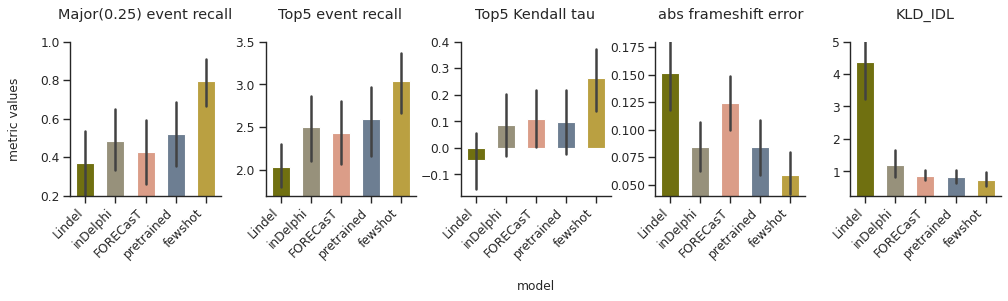

In [18]:
mouse_mESC = EmbryoAnalysis(foldnum=52, cell='mESC', archive_folder= 
'pl_trainer_log/True_mESC_featv5_c20_ST_DeepDecay_mul_identity_lr0.0003_L20.4_T0.5/mouse', 
metrics_to_show=['Major(0.25) event recall', 'Top5 event recall', 'Top5 Kendall tau', 'abs frameshift error','KLD_IDL'], 
r2=0.8, count=1000, dpi=80)

mouse_mESC.metric_fig.savefig("results/pub_figures/mouse_mESC/mouse_mESC_metrics.pdf", dpi=600, transparent=True);

In [21]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
mouse_mESC.perform_df.groupby('fix_setting').mean(numeric_only=True) #.to_csv('results/mouse_performance.csv')


,Top1 event recall,Top5 event recall,KL Divergence,Top5 Kendall tau,abs frameshift error,Major(0.25) event recall,KLD_IDL,Kendall_tau_IDL,Top1_IDL,Top5_IDL,Kendall_Top3_IDL,Kendall_Top5_IDL
fix_setting,,,,,,,,,,,,
FORECasT,0.666667,2.433333,1.365451,0.109714,0.124380,0.425926,0.866663,0.380043,0.666667,3.033333,0.156481,0.181333
Lindel,0.566667,2.033333,4.874200,-0.047111,0.151126,0.370370,4.357735,0.278298,0.600000,2.500000,0.027778,0.022667
fewshot,0.666667,3.033333,1.134008,0.264333,0.058759,0.796296,0.741974,0.475422,0.633333,3.333333,0.200926,0.287444
inDelphi,0.533333,2.500000,1.719492,0.085857,0.083811,0.481481,1.185083,0.434681,0.533333,3.000000,0.070370,0.157667
pretrained,0.566667,2.600000,1.192588,0.095413,0.083845,0.518519,0.816999,0.461237,0.600000,3.033333,0.100000,0.156667


In [ ]:
kde_fig = mouse_mESC.draw_kde()
kde_fig.savefig("results/pub_figures/mouse_mESC/mouse_mESC_kde.pdf", dpi=600, transparent=True)

kde_fig.gca().set_xlim(10,32);
kde_fig.savefig("results/pub_figures/mouse_mESC/mouse_mESC_kde_shorter.pdf", dpi=600, transparent=True)

In [9]:
fig_ls = mouse_mESC.draw_metrics(save_dir="results/pub_figures/mouse_mESC/mouse_by_genes");

In [17]:
for i, oligo in enumerate(mouse_mESC.melt_dfs.keys()):
    fig_ls[i].savefig(os.path.join('results/pub_figures/mouse_mESC/mouse_by_genes', f'{oligo}.pdf'), dpi=600, transparent=True, bbox_inches='tight')

# livestock (fig 5)

In [ ]:
allperform=[]
for cell in ['mESC', 'iPSC', 'K562', 'HAP1', 'CHO']:
    species=EmbryoAnalysis(foldnum=12, cell=cell, archive_folder= 
    f'pl_trainer_log/True_{cell}_featv5_c20_ST_DeepDecay_mul_identity_lr0.0003_L20.5_T0.5/species', 
    metrics_to_show=['Major(0.25) event recall', 'Top1 event recall','abs frameshift error','KLD_IDL'], r2=0.8, count=0, dpi=30)
    allperform.append(species.perform_df)
species_metrics_df = pd.concat(allperform).groupby(['fix_setting','cell']).mean(numeric_only=True)

Only high-quality (r2 >0.8 and count >0) samples (count = 9) were considered for performance metrics


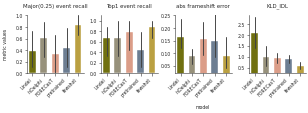

In [22]:
cell = "CHO"

save_dir = 'results/pub_figures/livestock_CHO_Aug11'

livestock_CHO = EmbryoAnalysis(foldnum=12, cell=cell, archive_folder= 
    f'pl_trainer_log/True_{cell}_featv5_c20_ST_DeepDecay_mul_identity_lr0.0003_L20.5_T0.5/species', 
    metrics_to_show=['Major(0.25) event recall', 'Top1 event recall','abs frameshift error','KLD_IDL'], r2=0.8, count=0, dpi=30)

livestock_CHO.metric_fig.savefig(os.path.join(save_dir, 'CHO_metrics.pdf'), dpi=600, transparent=True, bbox_inches='tight')

In [ ]:
kde_fig = livestock_CHO.draw_kde()
kde_fig.savefig(os.path.join(save_dir, 'CHO_kde_plot.pdf'), dpi=600, transparent=True, bbox_inches='tight')

In [ ]:
plt.ioff()
livestock_CHO.draw_metrics(save_dir='results/pub_figures/livestock_CHO_Aug11/indels_plot');